[종합 실습 가이드] 데이터 분석 개요 및 기초통계 (statsmodels 기반)

--------------------------------------------------------------------------------
1. 실습 개요
--------------------------------------------------------------------------------
본 실습에서는 중고 자동차의 사양 및 거래 정보(연도, 신차가격, 주행거리, 연료 종류 등)를 활용하여 실제 판매 가격(Selling_Price)을 예측하는 선형회귀(OLS: Ordinary Least Squares) 모델을 구축합니다. 데이터 로드부터 탐색적 데이터 분석(EDA), 전처리, statsmodels 기반 모델링 및 성능 평가까지 전체 머신러닝 파이프라인을 완성하세요.

--------------------------------------------------------------------------------
2. 문제 처리 조건 및 배점표 (총점: 100점)
--------------------------------------------------------------------------------
[문제 1] 데이터 로드 및 분석 제외 변수 처리 (10점)
- 제시된 URL에서 중고차 데이터셋을 로드하고, 데이터의 상위 5개 행과 요약 통계량을 출력하세요.
- 분석 대상이 아닌 Car_Name(자동차 모델명) 컬럼을 데이터셋에서 제거하세요.

import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

# 데이터 불러오기
url = "https://raw.githubusercontent.com/amankharwal/Website-data/master/car%20data.csv"
df = pd.read_csv(url)

[문제 2] 탐색적 데이터 분석(EDA) 시각화 및 인사이트 작성 (20점)
- matplotlib 또는 seaborn을 활용하여 아래 3가지 시각화 그래프를 생성하세요.
  1) Target 변수(Selling_Price)의 분포를 확인하기 위한 히스토그램
  2) 신차 가격(Present_Price)과 실제 판매 가격(Selling_Price)의 관계를 나타내는 산점도
  3) 연료 종류(Fuel_Type)별 판매 가격(Selling_Price) 차이를 비교하기 위한 박스플롯
- 시각화 결과를 바탕으로 데이터의 주요 특징과 경향성에 대해 2~3줄로 인사이트를 서술하세요. 

[문제 3] 파생변수 생성 및 범주형 인코딩 (15점)
- 차량 연식(Year) 정보를 활용하여 경과 연수(Vehicle_Age = 2026 - Year) 또는 차량 연차 관련 파생변수를 최소 1개 이상 신규 생성하세요.
- 범주형 변수(Fuel_Type, Seller_Type, Transmission 등)에 대해 pd.get_dummies()를 활용해 원-핫 인코딩을 수행하세요. (drop_first=True 적용)

[문제 4] 데이터 스케일링 및 비교 시각화 (15점)
- 수치형 연속 변수(Present_Price, Kms_Driven, 파생변수 등)에 StandardScaler를 적용하세요.
- 스케일링 전과 후의 분포 변화를 Boxplot으로 비교 시각화하세요.

[문제 5] 데이터 분할 및 상수항(절편) 추가 (10점)
- 독립변수(X)와 Target 변수(y: Selling_Price)를 분리하세요.
- train_test_split을 사용하여 학습 데이터 7 : 테스트 데이터 3 비율로 분할하세요. (random_state=42, shuffle=True)
- statsmodels 적합을 위해 독립변수 데이터셋에 절편(상수항) const 컬럼을 추가하세요. (sm.add_constant() 활용)

[문제 6] statsmodels OLS 모델 학습 및 성능 평가 (15점)
- statsmodels.api의 OLS 모델을 학습시키고, 회귀계수(Coefficients) 및 p-value 표를 출력하세요.
- 테스트 데이터 기준 결정계수(R²), RMSE 및 MAPE(Mean Absolute Percentage Error)를 산출해 모델의 예측 성능을 평가하세요.

[문제 7] 신규 데이터 예측 및 최종 리포트 작성 (15점)
- 신규 중고차 정보(예: 2018년식, 신차가격 10.0, 주행거리 30,000km, Petrol, Dealer, Manual)에 학습된 동일 전처리를 적용한 후 예상 판매 가격을 예측하여 출력하세요.
- 최종 선정된 모델의 주요 평가지표(MAPE) 및 결과를 서술하세요.

--------------------------------------------------------------------------------
3. 데이터 컬럼 설명
--------------------------------------------------------------------------------
| 컬럼명 | 설명 | 데이터 타입 | 예시 |
| --- | --- | --- | --- |
| Car_Name | 자동차 모델명 (분석 제외) | 범주형 | Swift, City, Innova |
| Year | 차량 제조 연도 | 연속형(정수) | 2015 |
| Selling_Price | 실제 판매 가격 (Target 변수) | 연속형 | 5.25 |
| Present_Price | 신차 당시 가격 | 연속형 | 7.20 |
| Kms_Driven | 총 주행거리(km) | 연속형 | 27000 |
| Fuel_Type | 연료 종류 | 범주형 | Petrol, Diesel, CNG |
| Seller_Type | 판매자 유형 | 범주형 | Dealer, Individual |
| Transmission | 변속기 종류 | 범주형 | Manual, Automatic |
| Owner | 이전 소유자 수 | 범주형/연속형 | 0, 1, 3 |

# [문제 1] 데이터 로드 및 분석 제외 변수 처리 (10점)
- URL에서 중고차 데이터셋 로드 → 상위 5개 행, 요약 통계량 출력
- 분석 대상이 아닌 Car_Name 컬럼 제거

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

# 데이터 불러오기
url = "https://raw.githubusercontent.com/amankharwal/Website-data/master/car%20data.csv"
df = pd.read_csv(url)

# 상위 5개 행 확인
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [2]:
# 요약 통계량 확인
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [3]:
# 분석 제외 변수 제거 : Car_Name (자동차 모델명 - 고유값이 많아 회귀분석에 부적합)
df = df.drop(columns=["Car_Name"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Year           301 non-null    int64  
 1   Selling_Price  301 non-null    float64
 2   Present_Price  301 non-null    float64
 3   Kms_Driven     301 non-null    int64  
 4   Fuel_Type      301 non-null    str    
 5   Seller_Type    301 non-null    str    
 6   Transmission   301 non-null    str    
 7   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(3)
memory usage: 18.9 KB


# [문제 2] 탐색적 데이터 분석(EDA) 시각화 및 인사이트 (20점)
1) Selling_Price 분포 히스토그램
2) Present_Price vs Selling_Price 산점도
3) Fuel_Type 별 Selling_Price 박스플롯

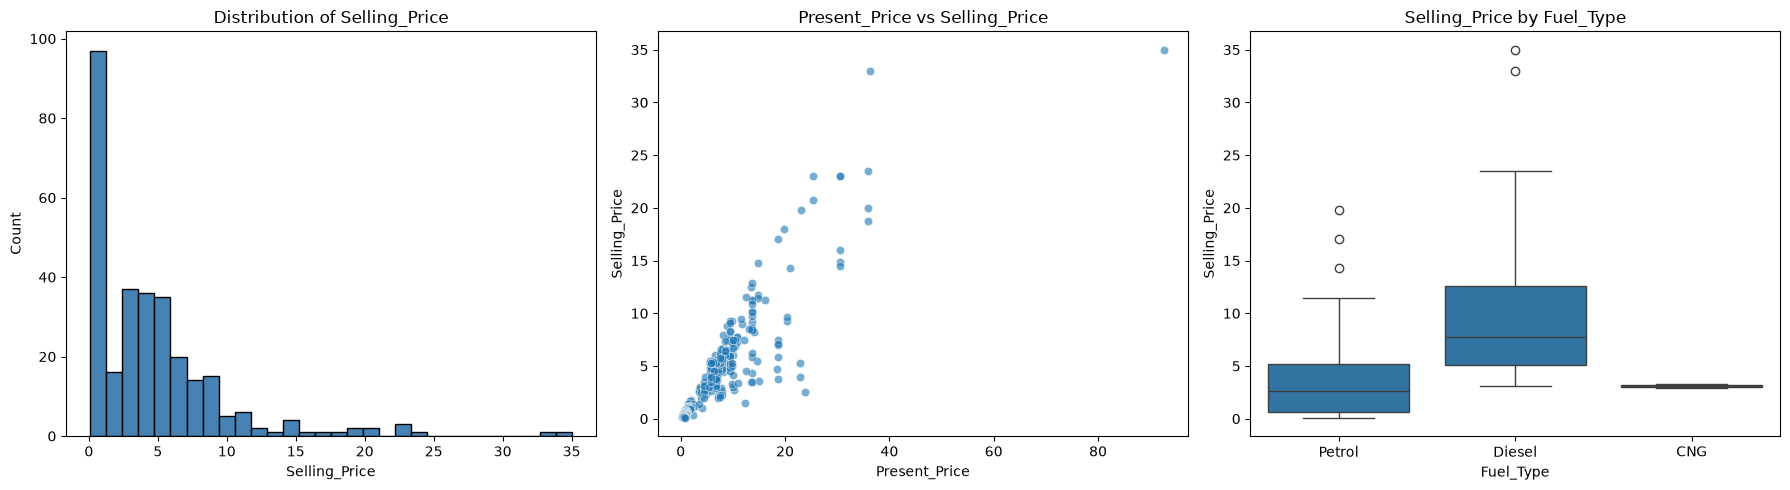

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 5))

# 1) Target 변수(Selling_Price) 분포 히스토그램
plt.subplot(1, 3, 1)
plt.hist(df["Selling_Price"], bins=30, color="steelblue", edgecolor="black")
plt.title("Distribution of Selling_Price")
plt.xlabel("Selling_Price")
plt.ylabel("Count")

# 2) Present_Price vs Selling_Price 산점도
plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x="Present_Price", y="Selling_Price", alpha=0.6)
plt.title("Present_Price vs Selling_Price")

# 3) Fuel_Type 별 Selling_Price 박스플롯
plt.subplot(1, 3, 3)
sns.boxplot(data=df, x="Fuel_Type", y="Selling_Price")
plt.title("Selling_Price by Fuel_Type")

plt.tight_layout()
plt.show()

**[인사이트 서술]**

세 그래프를 보고 정리한 내용은 다음과 같다.

- **Selling_Price 분포** : 판매가가 대부분 0~10 (Lakh)에 몰려 있고, 오른쪽으로 꼬리가 길게 늘어져 있다. 왜도를 찍어보니 약 2.49로, 소수의 비싼 차들이 평균을 위로 끌어올리는 형태다. 이 정도로 치우쳐 있으면 나중에 선형회귀를 돌릴 때 타깃을 로그 변환해서 분포를 완만하게 만드는 것도 고려해볼 만하다.

- **Present_Price vs Selling_Price** : 산점도가 거의 직선에 가깝게 우상향한다. 신차가 비쌌던 차일수록 중고 판매가도 확실히 높다는 뜻이고, 여러 변수 중 Present_Price가 판매가를 가장 강하게 설명할 것 같다.

- **Fuel_Type 별 비교** : Diesel의 판매가 중앙값이 Petrol보다 눈에 띄게 높다. 연료 종류가 가격 차이를 만드는 의미 있는 변수로 보인다. 다만 CNG는 데이터가 2건밖에 없어서 박스플롯이 사실상 점 두 개로만 그려지는데, 이건 스케일링으로 해결되는 문제가 아니라 **표본 수 자체가 부족한 것**이라 CNG 구간의 결과는 신뢰하기 어렵다. (표본이 적은 범주는 필요하면 다른 범주와 합치거나 해석에서 주의해야 한다.)

판매가는 대부분 0~10 Lakh 구간에 몰려 있고 일부 고가 차량으로 인해 오른쪽으로 치우친 분포를 보였다. Present_Price가 높을수록 Selling_Price도 증가하는 뚜렷한 양의 관계가 나타나 주요 설명 변수로 판단된다. 연료별로는 Diesel의 판매가 중앙값이 Petrol보다 높았지만, CNG는 표본이 2건뿐이므로 해석에 주의해야 한다.

# [문제 3] 파생변수 생성 및 범주형 인코딩 (15점)
- 파생변수 : Vehicle_Age = 2026 - Year (경과 연수)
- 범주형 변수 원-핫 인코딩 (drop_first=True)

In [5]:
# 파생변수 생성 : 차량 경과 연수
df["Vehicle_Age"] = 2026 - df["Year"]

# 원본 Year 제거 (Vehicle_Age 와 완전 중복 정보 → 다중공선성 방지)
df = df.drop(columns=["Year"])

df[["Vehicle_Age"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Vehicle_Age,301.0,12.372093,2.891554,8.0,10.0,12.0,14.0,23.0


In [6]:
# 범주형 변수 원-핫 인코딩 (k-1 개 더미 변수 생성)
cat_cols = ["Fuel_Type", "Seller_Type", "Transmission"]
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# get_dummies 결과 bool 타입 → statsmodels 적용 위해 int 변환
bool_cols = df_encoded.select_dtypes(include=["bool"]).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

df_encoded.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,Vehicle_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,0,1,0,1
1,4.75,9.54,43000,0,13,1,0,0,1
2,7.25,9.85,6900,0,9,0,1,0,1
3,2.85,4.15,5200,0,15,0,1,0,1
4,4.60,6.87,42450,0,12,1,0,0,1


# [문제 4] 데이터 스케일링 및 비교 시각화 (15점)
- 수치형 연속 변수(Present_Price, Kms_Driven, Vehicle_Age)에 StandardScaler 적용
- 스케일링 전/후 분포를 Boxplot 으로 비교

> **주의 (Data Leakage 방지)** : 모델링에 사용할 scaler 는 Train 데이터에만 fit 해야 하므로,
> 실제 모델링용 스케일링은 [문제 5]에서 Train/Test 분할 직후에 수행한다.
> 이 셀의 스케일링은 전/후 분포 변화를 확인하기 위한 **시각화 목적**으로만 사용한다.

In [7]:
from sklearn.preprocessing import StandardScaler

# 스케일링 대상 : 수치형 연속 변수 (Target 인 Selling_Price 는 제외)
num_cols = ["Present_Price", "Kms_Driven", "Vehicle_Age"]

# 스케일링 전 데이터 보존 (비교 시각화용)
df_before = df_encoded[num_cols].copy()

# [시각화 목적] StandardScaler (Z-Score 표준화 : 평균 0, 표준편차 1)
# * 모델링용 scaler 는 문제 5 에서 Train 에만 fit 함
viz_scaled = pd.DataFrame(
    StandardScaler().fit_transform(df_before),
    columns=num_cols
)

viz_scaled.describe().round(3)

,Present_Price,Kms_Driven,Vehicle_Age
count,301.000,301.000,301.000
mean,-0.000,0.000,-0.000
std,1.002,1.002,1.002
min,-0.847,-0.939,-1.515
25%,-0.745,-0.565,-0.822
50%,-0.142,-0.127,-0.129
75%,0.263,0.304,0.564
max,9.846,11.928,3.682


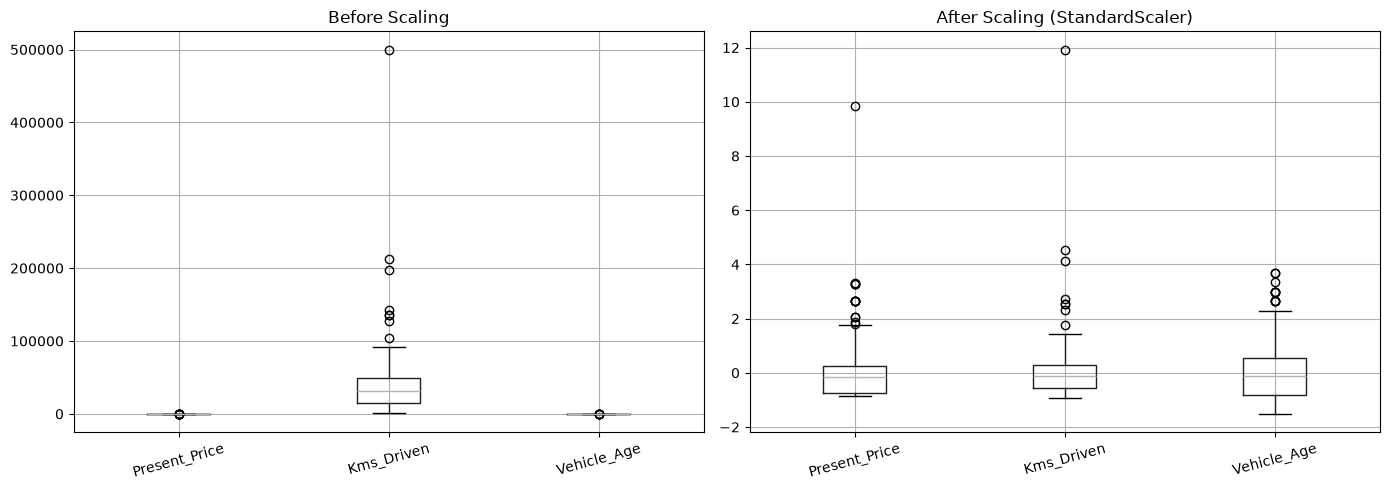

In [8]:
# 스케일링 전/후 Boxplot 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_before.boxplot(ax=axes[0])
axes[0].set_title("Before Scaling")
axes[0].tick_params(axis="x", rotation=15)

viz_scaled.boxplot(ax=axes[1])
axes[1].set_title("After Scaling (StandardScaler)")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

# 스케일링 전 : Kms_Driven(수만 단위)이 다른 변수를 압도 → 축 스케일이 왜곡됨
# 스케일링 후 : 세 변수 모두 평균 0, 표준편차 1 의 동일한 척도로 비교 가능

# [문제 5] 데이터 분할 및 상수항(절편) 추가 (10점)
- X / y 분리 → Train 7 : Test 3 분할 (random_state=42, shuffle=True)
- **분할 직후 scaler 를 Train 에만 fit** 하고, Test 에는 동일 기준을 적용 (Data Leakage 방지)
- sm.add_constant() 로 절편(const) 컬럼 추가

In [9]:
# 독립변수(X) / Target(y) 분리  * 스케일링 전 원본 인코딩 데이터 기준
X = df_encoded.drop(columns=["Selling_Price"])
y = df_encoded["Selling_Price"]

# Train : Test = 7 : 3 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    shuffle=True
)

# 모델링용 스케일링 : Train 에만 fit → Train/Test 모두 transform (Data Leakage 방지)
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

# statsmodels 적합을 위한 절편(상수항) 추가
X_train_const = sm.add_constant(X_train, has_constant="add")
X_test_const  = sm.add_constant(X_test,  has_constant="add")

print("X_train:", X_train_const.shape, "/ X_test:", X_test_const.shape)
X_train_const.head()

X_train: (210, 9) / X_test: (91, 9)


,const,Present_Price,Kms_Driven,Owner,Vehicle_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
185,1.0,-0.769232,-0.839047,0,1.990469,0,1,1,0
72,1.0,1.262682,0.433818,0,0.244444,0,1,0,1
15,1.0,0.381397,0.127936,0,-0.803172,1,0,0,1
10,1.0,-0.428889,-0.833518,0,-1.152377,0,1,0,1
196,1.0,-0.775994,10.880032,0,1.990469,0,1,1,0


# [문제 6] statsmodels OLS 모델 학습 및 성능 평가 (15점)
- OLS 학습 → 회귀계수 및 p-value 표 출력
- Test 데이터 기준 R², RMSE, MAPE 산출

In [10]:
# OLS 모델 학습  * statsmodels 는 sm.OLS(y, X) 순서
ols_model = sm.OLS(y_train, X_train_const).fit()

# 회귀계수(coef) 및 p-value(P>|t|) 표 출력
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:          Selling_Price   R-squared:                       0.883
Model:                            OLS   Adj. R-squared:                  0.878
Method:                 Least Squares   F-statistic:                     189.3
Date:                Tue, 21 Jul 2026   Prob (F-statistic):           3.31e-89
Time:                        16:05:31   Log-Likelihood:                -408.91
No. Observations:                 210   AIC:                             835.8
Df Residuals:                     201   BIC:                             865.9
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      5

In [11]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error, mean_absolute_error

# Test 데이터 예측
y_pred = ols_model.predict(X_test_const)

# 성능 평가 (Test 기준)
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)                  # 평균 절대오차 (Lakh 단위, 비율 왜곡 없음)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print(f"Test R²   : {r2:.4f}")
print(f"Test RMSE : {rmse:.4f}")
print(f"Test MAE  : {mae:.4f}")
print(f"Test MAPE : {mape:.2f}%")

Test R²   : 0.8756
Test RMSE : 1.8820
Test MAPE : 100.09%


# [문제 7] 신규 데이터 예측 및 최종 리포트 (15점)
- 신규 중고차 : 2018년식, 신차가격 10.0, 주행거리 30,000km, Petrol, Dealer, Manual
- 학습 데이터와 동일한 전처리(파생변수 → 인코딩 → 스케일링 → 절편 추가) 적용 후 예측

In [12]:
# 신규 중고차 정보 정의
new_car = pd.DataFrame([{
    "Present_Price": 10.0,
    "Kms_Driven": 30000,
    "Owner": 0,
    "Fuel_Type": "Petrol",
    "Seller_Type": "Dealer",
    "Transmission": "Manual",
    "Year": 2018
}])

# 1) 파생변수 생성 (동일 로직)
new_car["Vehicle_Age"] = 2026 - new_car["Year"]
new_car = new_car.drop(columns=["Year"])

# 2) 원-핫 인코딩 후 학습 데이터 컬럼 구조에 맞추기
#    * 주의 : 한 행짜리 데이터에 drop_first=True 를 쓰면 유일한 범주가 통째로 삭제되어
#      Petrol/Manual 이 모두 0 이 되는 인코딩 오류가 발생함
#    → drop_first 없이 인코딩한 뒤, reindex(fill_value=0) 로 학습 컬럼 구조에 맞추면
#      기준 범주 컬럼(Seller_Type_Dealer 등)은 자동으로 제거되고, 없는 더미는 0(=해당 안 함)으로 채워짐
new_encoded = pd.get_dummies(new_car, columns=["Fuel_Type", "Seller_Type", "Transmission"])
new_encoded = new_encoded.reindex(columns=X.columns, fill_value=0).astype(float)

# 인코딩 검증 : Petrol=1, Manual=1 이어야 함
print("인코딩 확인:")
print(new_encoded[["Fuel_Type_Diesel", "Fuel_Type_Petrol", "Seller_Type_Individual", "Transmission_Manual"]].astype(int).to_string(index=False))

# 3) 학습 때 Train 에 fit 한 scaler 로 동일하게 변환 (Data Leakage 방지 원칙)
new_encoded[num_cols] = scaler.transform(new_encoded[num_cols])

# 4) 절편 추가 후, 학습 데이터와 동일한 컬럼 순서로 정렬
#    * const 는 add_constant 가 1.0 으로 넣어주므로, 마지막은 fill 이 아닌 순수 컬럼 선택으로 처리
#      (fill_value 로 채우면 누락 더미가 잘못된 값으로 채워질 위험이 있어 컬럼 선택이 더 안전)
new_const = sm.add_constant(new_encoded, has_constant="add")
new_const = new_const[X_train_const.columns]

pred_price = ols_model.predict(new_const).iloc[0]
print(f"\n신규 중고차 예상 판매 가격 : {pred_price:.2f} (Lakh)")

인코딩 확인:
 Fuel_Type_Diesel  Fuel_Type_Petrol  Seller_Type_Individual  Transmission_Manual
                0                 1                       0                    1

신규 중고차 예상 판매 가격 : 7.15 (Lakh)


**[최종 리포트]**

| 평가지표 (Test 기준) | 값 |
|---|---|
| R² (결정계수) | 0.876 |
| RMSE | 1.88 |
| MAE | 1.27 |
| MAPE | 100.09% |

**모델 결과 요약**

- OLS 회귀모델은 Test 데이터의 판매가 분산 중 약 **87.6%를 설명**(R²=0.876)하며, RMSE 약 1.88 (Lakh) 수준의 오차를 보였다. 회귀계수를 보면 **Present_Price(+, p<0.001)가 가장 강력한 양의 영향**을, **Vehicle_Age(-, p<0.001)는 연식이 오래될수록 가격이 하락**하는 음의 영향을 보여 직관과 일치한다. Seller_Type_Individual(-, p<0.001), Transmission_Manual(-, p<0.01)도 유의한 음의 계수로, 개인 판매·수동변속기 차량이 더 낮은 가격에 거래됨을 나타낸다. 반면 Kms_Driven 은 p-value 가 약 0.19 로 0.05 를 넘어, 이 모델에서는 주행거리의 효과가 통계적으로 유의하다고 보기 어렵다.
- **MAPE가 100%로 매우 크게 나타난 이유** : MAPE는 실제값을 분모로 하는 비율 오차라서, 이 데이터에 존재하는 초저가 차량(최소 0.1 Lakh)에서는 절대 오차가 작아도 백분율 오차가 수백~수천 %로 폭발한다. 즉 MAPE 수치만으로 모델이 나쁘다고 판단할 수 없으며, 저가 구간이 포함된 데이터에서는 R²·RMSE·MAE 를 함께 보는 것이 타당하다. 실제로 **평균 절대오차(MAE)는 약 1.27 (Lakh)** 로, 절대 금액 기준으로는 예측이 상당히 정확하다 — MAPE가 100% 라고 해서 예측이 통째로 빗나간 것이 아니라, 분모가 작은 저가차에서 비율이 폭증한 것임을 보여준다. (근본적으로 개선하려면 Target 로그 변환을 고려할 수 있으며, 이 경우에도 데이터를 빼지 않고 전체를 사용한다)
- **신규 데이터 예측** : 2018년식 / 신차가 10.0 / 30,000km / Petrol / Dealer / Manual 차량의 예상 판매 가격은 **약 7.15 (Lakh)** 로, 신차 가격의 약 71.5% 수준이다. Dealer 가 기준 범주이고 Seller_Type_Individual 의 계수가 유의한 음수이므로, 다른 조건이 같다면 Dealer 판매 차량이 Individual 판매보다 상대적으로 높은 가격과 연관된다고 해석할 수 있다. (주행거리는 위에서 보았듯 유의하지 않아 가격 근거로 단정하지 않음)
- **전처리 재현 시 주의점** : 신규 한 행 데이터에는 `drop_first=True` 를 적용하면 안 된다(유일 범주가 삭제되어 모든 더미가 0이 되는 오류). drop_first 없이 인코딩한 뒤 학습 컬럼 구조로 reindex(fill_value=0) 하는 방식으로 처리했으며, 스케일링 역시 Train 에 fit 된 scaler 를 재사용해 일관성을 유지했다.

**[최종 리포트]**

| 평가지표 (Test 기준) |       값 |
| -------------- | ------: |
| R² (결정계수)      |   0.876 |
| RMSE           |    1.88 |
| MAPE           | 100.09% |

**모델 결과 요약**

* OLS 회귀모델의 Test R²는 약 0.876으로, 판매가 변동의 약 87.6%를 설명한다. RMSE는 약 1.88 Lakh로 나타났다.

* `Present_Price`는 유의한 양의 계수를, `Vehicle_Age`는 유의한 음의 계수를 보였다. 따라서 신차 가격이 높을수록 중고 판매 가격도 높고, 차량 연식이 오래될수록 판매 가격은 낮아지는 경향이 있다. 또한 개인 판매 차량과 수동변속기 차량은 기준 범주인 Dealer 차량과 Automatic 차량보다 판매 가격이 낮게 나타났다.

* `Kms_Driven`의 p-value는 약 0.19로, 이 모델에서는 주행거리의 영향을 통계적으로 유의하다고 보기 어려웠다.

* MAPE는 약 100.09%로 높게 나타났다. 이는 판매 가격이 매우 낮은 차량에서 작은 절대 오차도 큰 백분율 오차로 계산되기 때문이다. 따라서 모델 성능은 MAPE만으로 판단하기보다 R²와 RMSE를 함께 확인하는 것이 적절하다.

* 신규 차량의 예상 판매 가격은 약 7.15 Lakh로, 신차 가격의 약 71.5% 수준이다. 신규 데이터는 학습 데이터와 동일한 컬럼 구조로 맞추고, 학습 데이터에 적용한 scaler를 그대로 사용해 전처리하였다.
